# Phase 4 — Model Building & Evaluation
### Early Disease Prediction Using Healthcare Data Warehouse

**Objective:** Train and compare five classifiers on each disease dataset,
apply the correct imbalance strategy per dataset, and evaluate with a full
clinical metrics suite.

| Model | Type | Imbalance Handling |
|---|---|---|
| Logistic Regression | Linear baseline | `class_weight='balanced'` |
| Decision Tree | Interpretable tree | `class_weight='balanced'` |
| Random Forest | Ensemble (bagging) | `class_weight='balanced'` |
| XGBoost | Ensemble (boosting) | `scale_pos_weight` |
| LightGBM | Ensemble (boosting) | `class_weight='balanced'` |

**Stroke-specific:** SMOTE is applied *inside* each CV fold (via imblearn Pipeline)
to prevent data leakage into validation folds.

---
**Evaluation metrics used:**
`Accuracy · Precision · Recall · F1 · Specificity · ROC-AUC · PR-AUC · MCC`

> For stroke, **Recall and PR-AUC** are the primary metrics because a missed
> stroke (False Negative) has far greater clinical cost than a false alarm.

In [1]:
import os
import warnings
import joblib
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.ticker  as mticker
import seaborn as sns
from pathlib import Path

from sklearn.base            import clone
from sklearn.model_selection import cross_val_score
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay,
)

try:
    from xgboost import XGBClassifier
    XGB_OK = True
    print("XGBoost   : OK")
except ImportError:
    XGB_OK = False
    print("WARNING: XGBoost not installed — pip install xgboost")

try:
    from lightgbm import LGBMClassifier
    LGB_OK = True
    print("LightGBM  : OK")
except ImportError:
    LGB_OK = False
    print("WARNING: LightGBM not installed — pip install lightgbm")

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline      import Pipeline as ImbPipeline
    SMOTE_OK = True
    print("SMOTE     : OK")
except ImportError:
    SMOTE_OK = False
    print("WARNING: imbalanced-learn not installed — pip install imbalanced-learn")

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'      : 110,
    'figure.facecolor': 'white',
    'axes.titleweight': 'bold',
    'axes.titlesize'  : 12,
})

_cwd  = Path.cwd()
ROOT  = _cwd.parent if _cwd.name == 'models' else _cwd
SAVED = ROOT / 'models'  / 'saved'
FIGS  = ROOT / 'reports' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

def savefig(fname):
    plt.savefig(FIGS / fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"  [SAVED] reports/figures/{fname}")

print(f"\nROOT  : {ROOT}")
print(f"SAVED : {SAVED}")

XGBoost   : OK


LightGBM  : OK


SMOTE     : OK

ROOT  : D:\NMU\Data Mining\Early Disease Prediction Using Healthcare Data Warehouse
SAVED : D:\NMU\Data Mining\Early Disease Prediction Using Healthcare Data Warehouse\models\saved


In [2]:
art_a = joblib.load(SAVED / 'autism_artifacts.pkl')
art_d = joblib.load(SAVED / 'diabetes_artifacts.pkl')
art_s = joblib.load(SAVED / 'stroke_artifacts.pkl')

def spw_ratio(y_tr):
    '''Compute scale_pos_weight = n_negative / n_positive for XGBoost.'''
    n0 = int((y_tr == 0).sum())
    n1 = int((y_tr == 1).sum())
    return round(n0 / n1, 3)

SPW_A = spw_ratio(art_a['y_train'])
SPW_D = spw_ratio(art_d['y_train'])
SPW_S = art_s['scale_pos_weight']

print(f"{'Dataset':<22} {'Train':>7} {'Test':>6} {'Features':>9} {'SPW':>7}")
print("-" * 55)
for name, art, spw in [('Autism Screening', art_a, SPW_A),
                         ('Diabetes Risk',   art_d, SPW_D),
                         ('Stroke Prediction',art_s, SPW_S)]:
    print(f"{name:<22} {art['X_train'].shape[0]:>7,} "
          f"{art['X_test'].shape[0]:>6,} "
          f"{art['X_train'].shape[1]:>9} "
          f"{spw:>7.2f}")

Dataset                  Train   Test  Features     SPW
-------------------------------------------------------
Autism Screening         4,860  1,215        15    2.37
Diabetes Risk              416    104        16    0.62
Stroke Prediction        4,087  1,022        15   19.54


In [3]:
def train_evaluate(name, model, X_tr, y_tr, X_te, y_te, cv,
                   smote_cv=False, cv_X=None, cv_y=None):
    '''
    Train a classifier, cross-validate, then evaluate on the held-out test set.

    Parameters
    ----------
    smote_cv : bool
        If True, wrap model in an imblearn Pipeline so SMOTE is applied
        inside each CV fold (correct approach — prevents leakage).
    cv_X, cv_y : array-like, optional
        If provided, use these arrays for cross-validation scoring only
        (allows CV on original data while fitting on pre-SMOTE'd data).
    '''
    _cv_X = cv_X if cv_X is not None else X_tr
    _cv_y = cv_y if cv_y is not None else y_tr

    # -- Cross-validation --
    if smote_cv and SMOTE_OK:
        pipe  = ImbPipeline([
            ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
            ('clf',   clone(model)),
        ])
        cv_f1 = cross_val_score(pipe, _cv_X, _cv_y, cv=cv,
                                scoring='f1', n_jobs=1)
    else:
        cv_f1 = cross_val_score(model, _cv_X, _cv_y, cv=cv,
                                scoring='f1', n_jobs=-1)

    # -- Fit on full training set --
    model.fit(X_tr, y_tr)

    # -- Predict --
    y_pred  = model.predict(X_te)
    y_proba = (model.predict_proba(X_te)[:, 1]
               if hasattr(model, 'predict_proba') else None)

    # -- Metrics --
    cm             = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    spec           = tn / (tn + fp + 1e-9)

    return {
        'Model'       : name,
        'CV F1'       : round(float(cv_f1.mean()), 4),
        'CV F1 std'   : round(float(cv_f1.std()),  4),
        'Accuracy'    : round(accuracy_score(y_te, y_pred),                         4),
        'Precision'   : round(precision_score(y_te, y_pred, zero_division=0),       4),
        'Recall'      : round(recall_score(y_te, y_pred, zero_division=0),          4),
        'F1'          : round(f1_score(y_te, y_pred, zero_division=0),              4),
        'Specificity' : round(spec,                                                 4),
        'ROC-AUC'     : round(roc_auc_score(y_te, y_proba),           4) if y_proba is not None else float('nan'),
        'PR-AUC'      : round(average_precision_score(y_te, y_proba), 4) if y_proba is not None else float('nan'),
        'MCC'         : round(matthews_corrcoef(y_te, y_pred),        4),
        # Private — used by plot helpers
        '_model'      : model,
        '_proba'      : y_proba,
        '_pred'       : y_pred,
        '_cm'         : cm,
    }

PUBLIC = ['Model', 'CV F1', 'CV F1 std', 'Accuracy',
          'Precision', 'Recall', 'F1', 'Specificity',
          'ROC-AUC', 'PR-AUC', 'MCC']

def results_df(results):
    return (pd.DataFrame([{k: v for k, v in r.items()
                            if not k.startswith('_')}
                           for r in results])
              .set_index('Model'))

print("train_evaluate() and results_df() defined.")

train_evaluate() and results_df() defined.


In [4]:
def plot_cms(results, title, figname):
    '''Plot a 1 x N grid of confusion matrices, one per model.'''
    n    = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4.8))
    fig.suptitle(f'{title}  —  Confusion Matrices', y=1.03)
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        disp = ConfusionMatrixDisplay(r['_cm'],
                                      display_labels=['Neg', 'Pos'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        tn, fp, fn, tp = r['_cm'].ravel()
        ax.set_title(r['Model'], fontsize=10)
        ax.set_xlabel(
            f"P={r['Precision']:.2f}  R={r['Recall']:.2f}"
            f"  F1={r['F1']:.2f}",
            fontsize=8.5)
    plt.tight_layout()
    savefig(figname)


def plot_roc_pr(results, y_te, title, figname):
    '''Overlay ROC curves and PR curves for all models on two side-by-side axes.'''
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title}  —  ROC & Precision-Recall Curves', y=1.03)
    palette = plt.cm.tab10(np.linspace(0, 0.9, len(results)))

    for r, c in zip(results, palette):
        if r['_proba'] is not None:
            # ROC
            fpr, tpr, _ = roc_curve(y_te, r['_proba'])
            axes[0].plot(fpr, tpr, color=c, lw=2,
                         label=f"{r['Model']}  (AUC={r['ROC-AUC']:.3f})")
            # PR
            prec, rec, _ = precision_recall_curve(y_te, r['_proba'])
            axes[1].plot(rec, prec, color=c, lw=2,
                         label=f"{r['Model']}  (AP={r['PR-AUC']:.3f})")

    # ROC diagonal
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
                title='ROC Curves')
    axes[0].legend(fontsize=8.5, loc='lower right')
    axes[0].spines[['top', 'right']].set_visible(False)

    # PR baseline
    baseline = float(np.mean(y_te))
    axes[1].axhline(baseline, color='grey', ls='--', lw=1,
                    label=f'No-skill baseline ({baseline:.3f})')
    axes[1].set(xlabel='Recall', ylabel='Precision',
                title='Precision-Recall Curves')
    axes[1].legend(fontsize=8.5, loc='upper right')
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    savefig(figname)

print("plot_cms() and plot_roc_pr() defined.")

plot_cms() and plot_roc_pr() defined.


In [5]:
def make_models(spw_val=1.0):
    '''
    Return a fresh dict of all 5 classifier instances.
    spw_val = scale_pos_weight for XGBoost (n_neg / n_pos in training set).
    '''
    mdls = {
        'Logistic Regression': LogisticRegression(
            C=0.1, max_iter=2000,
            class_weight='balanced',
            solver='lbfgs',
            random_state=RANDOM_STATE,
        ),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=7,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }
    if XGB_OK:
        mdls['XGBoost'] = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=spw_val,
            eval_metric='logloss',
            verbosity=0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if LGB_OK:
        mdls['LightGBM'] = LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            num_leaves=31,
            min_child_samples=20,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    return mdls

print(f"Model factory ready. Available classifiers: {list(make_models().keys())}")

Model factory ready. Available classifiers: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']

---
## 1 · Autism Screening — Model Training & Evaluation

**Dataset:** 6,075 records | 15 features | 80/20 stratified split
**Imbalance:** 1 : 2.4 (mild) — `class_weight='balanced'` for all models
**CV:** StratifiedKFold(k=5)

**Expected outcome:** High performance (F1 ≥ 0.92) is expected here.
The AQ Score feature provides a near-clinical threshold.
*If F1 ≥ 0.99, investigate for data leakage.*

**LR** uses scaled features; all other models use raw features.

In [6]:
models_a = make_models(spw_val=SPW_A)
cv_a     = art_a['cv']
results_a = []

for name, model in models_a.items():
    # LR needs scaled data; tree models use raw
    use_sc = (name == 'Logistic Regression')
    X_tr   = art_a['X_train_scaled'] if use_sc else art_a['X_train']
    X_te   = art_a['X_test_scaled']  if use_sc else art_a['X_test']

    print(f"  Training {name:<22}", end='', flush=True)
    r = train_evaluate(name, model, X_tr, art_a['y_train'],
                       X_te, art_a['y_test'], cv_a)
    results_a.append(r)
    print(f"  CV-F1={r['CV F1']:.4f}  F1={r['F1']:.4f}"
          f"  ROC-AUC={r['ROC-AUC']:.4f}  Recall={r['Recall']:.4f}")

print("\nAutism: all models trained.")

  Training Logistic Regression   

  CV-F1=0.8844  F1=0.8561  ROC-AUC=0.9561  Recall=0.9307
  Training Decision Tree         

  CV-F1=1.0000  F1=1.0000  ROC-AUC=1.0000  Recall=1.0000
  Training Random Forest         

  CV-F1=1.0000  F1=1.0000  ROC-AUC=1.0000  Recall=1.0000
  Training XGBoost               

  CV-F1=1.0000  F1=1.0000  ROC-AUC=1.0000  Recall=1.0000
  Training LightGBM              

  CV-F1=1.0000  F1=1.0000  ROC-AUC=1.0000  Recall=1.0000

Autism: all models trained.


In [7]:
df_results_a = results_df(results_a)

# Highlight best per column
style = (df_results_a.style
         .highlight_max(subset=['CV F1','Accuracy','Precision','Recall',
                                'F1','Specificity','ROC-AUC','PR-AUC','MCC'],
                        color='#c6efce')
         .highlight_min(subset=['CV F1 std'], color='#c6efce')
         .format(precision=4))

print("Autism Screening — Test-Set Evaluation Results:")
print("(Green = best per column)")
display(style)

Autism Screening — Test-Set Evaluation Results:
(Green = best per column)


,CV F1,CV F1 std,Accuracy,Precision,Recall,F1,Specificity,ROC-AUC,PR-AUC,MCC
Model,,,,,,,,,,
Logistic Regression,0.8844,0.0085,0.9070,0.7925,0.9307,0.8561,0.8970,0.9561,0.8615,0.7936
Decision Tree,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Random Forest,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
LightGBM,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


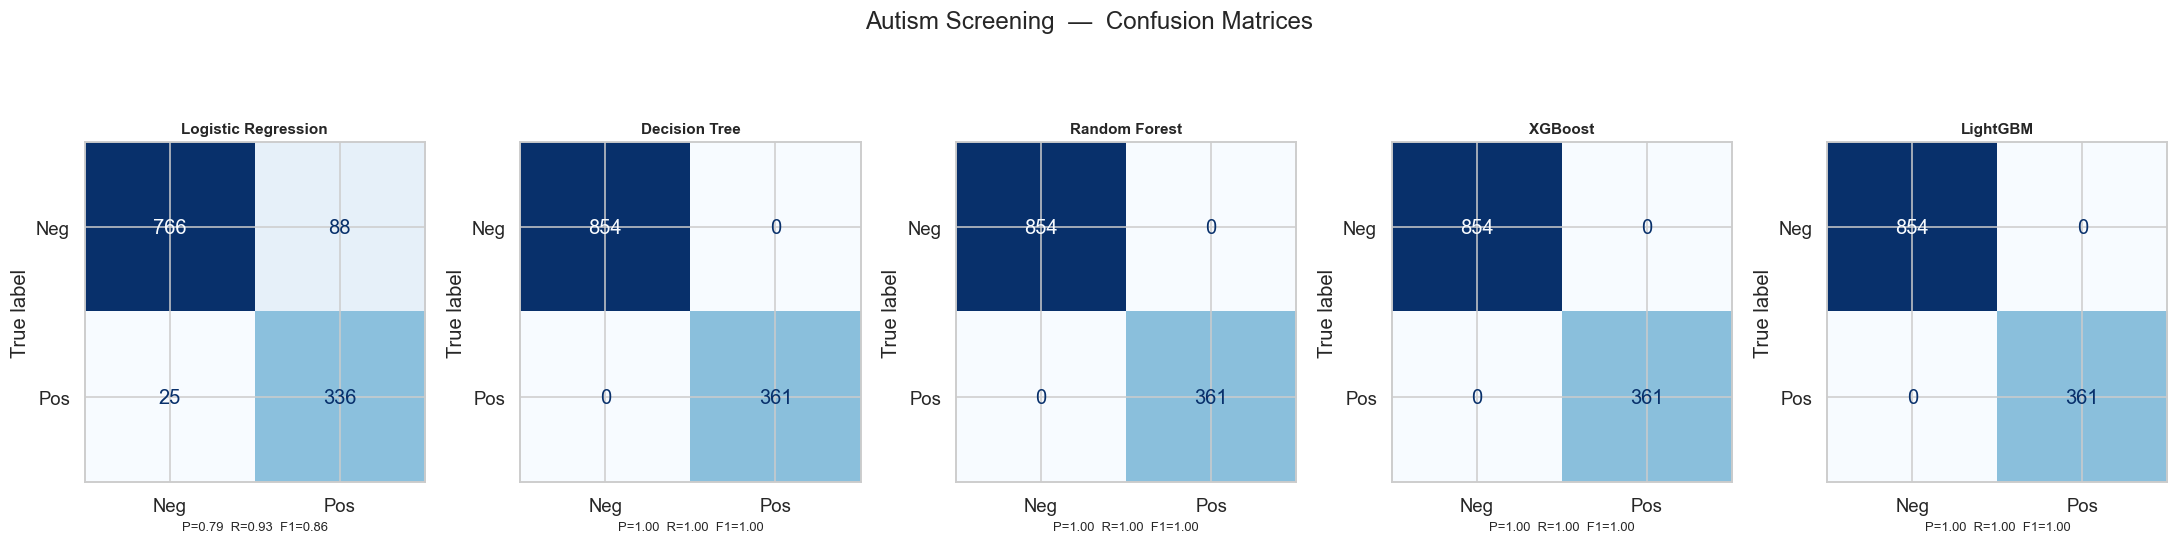

  [SAVED] reports/figures/20_autism_confusion_matrices.png


In [8]:
plot_cms(results_a,
         title='Autism Screening',
         figname='20_autism_confusion_matrices.png')

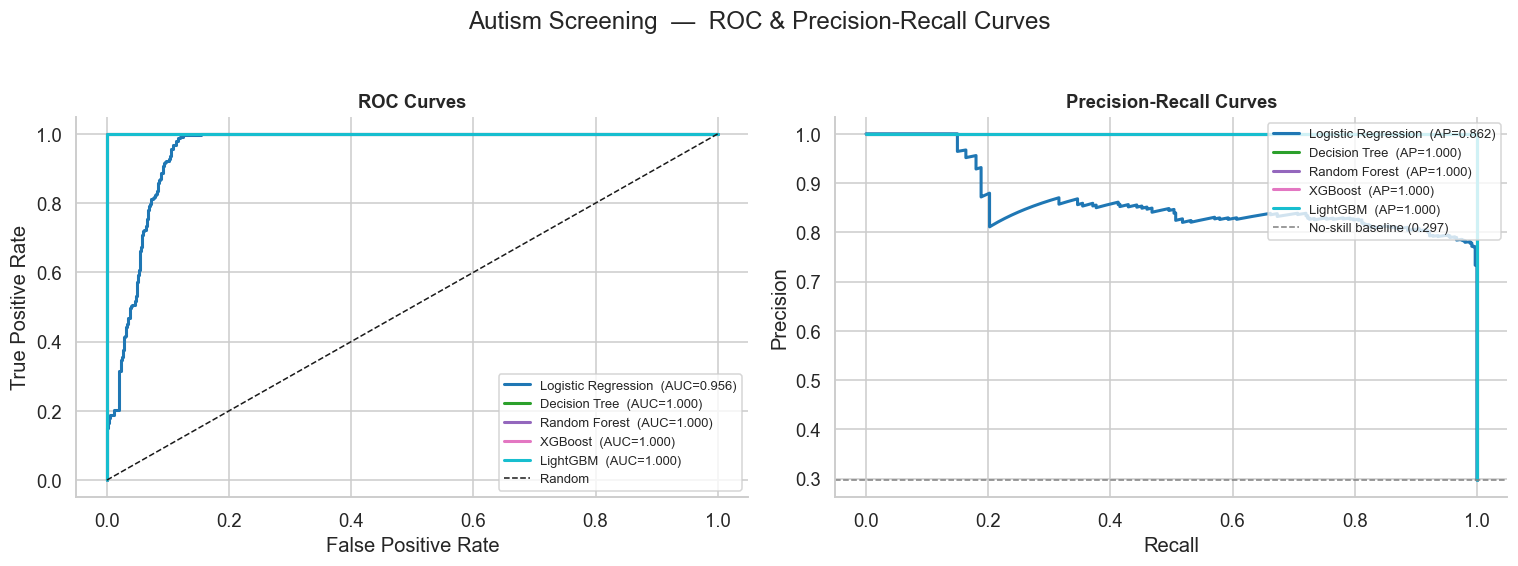

  [SAVED] reports/figures/21_autism_roc_pr.png

Best Autism model by F1: Decision Tree
  F1=1.0000  Recall=1.0000  PR-AUC=1.0000  MCC=1.0000


In [9]:
plot_roc_pr(results_a,
            y_te=art_a['y_test'],
            title='Autism Screening',
            figname='21_autism_roc_pr.png')

# Best model summary
best_a = max(results_a, key=lambda r: r['F1'])
print(f"\nBest Autism model by F1: {best_a['Model']}")
print(f"  F1={best_a['F1']:.4f}  Recall={best_a['Recall']:.4f}"
      f"  PR-AUC={best_a['PR-AUC']:.4f}  MCC={best_a['MCC']:.4f}")

---
## 2 · Diabetes Risk — Model Training & Evaluation

**Dataset:** 520 records | 16 features | 80/20 stratified split
**Imbalance:** 1 : 1.6 (mild) — `class_weight='balanced'`
**CV:** StratifiedKFold(k=10)  *(10 folds because n=520 is very small)*

**Risk:** With only 416 training samples, complex models can overfit.
Watch for large gaps between CV F1 and test F1.

Report **MCC** alongside F1 — it is the most reliable metric for
small, mildly imbalanced datasets.

In [10]:
models_d  = make_models(spw_val=SPW_D)
cv_d      = art_d['cv']
results_d = []

for name, model in models_d.items():
    use_sc = (name == 'Logistic Regression')
    X_tr   = art_d['X_train_scaled'] if use_sc else art_d['X_train']
    X_te   = art_d['X_test_scaled']  if use_sc else art_d['X_test']

    print(f"  Training {name:<22}", end='', flush=True)
    r = train_evaluate(name, model, X_tr, art_d['y_train'],
                       X_te, art_d['y_test'], cv_d)
    results_d.append(r)
    print(f"  CV-F1={r['CV F1']:.4f}  F1={r['F1']:.4f}"
          f"  ROC-AUC={r['ROC-AUC']:.4f}  MCC={r['MCC']:.4f}")

print("\nDiabetes: all models trained.")

  Training Logistic Regression   

  CV-F1=0.9090  F1=0.9333  ROC-AUC=0.9914  MCC=0.8539
  Training Decision Tree         

  CV-F1=0.9076  F1=0.9333  ROC-AUC=0.9957  MCC=0.8539
  Training Random Forest         

  CV-F1=0.9607  F1=0.9841  ROC-AUC=1.0000  MCC=0.9605
  Training XGBoost               

  CV-F1=0.9717  F1=0.9760  ROC-AUC=0.9996  MCC=0.9416
  Training LightGBM              

  CV-F1=0.9640  F1=0.9841  ROC-AUC=1.0000  MCC=0.9605

Diabetes: all models trained.


In [11]:
df_results_d = results_df(results_d)
style_d = (df_results_d.style
           .highlight_max(subset=['CV F1','Accuracy','Precision','Recall',
                                  'F1','Specificity','ROC-AUC','PR-AUC','MCC'],
                          color='#c6efce')
           .highlight_min(subset=['CV F1 std'], color='#c6efce')
           .format(precision=4))
print("Diabetes Risk — Test-Set Evaluation Results:")
display(style_d)

Diabetes Risk — Test-Set Evaluation Results:


,CV F1,CV F1 std,Accuracy,Precision,Recall,F1,Specificity,ROC-AUC,PR-AUC,MCC
Model,,,,,,,,,,
Logistic Regression,0.9090,0.0492,0.9231,1.0000,0.8750,0.9333,1.0000,0.9914,0.9949,0.8539
Decision Tree,0.9076,0.0635,0.9231,1.0000,0.8750,0.9333,1.0000,0.9957,0.9966,0.8539
Random Forest,0.9607,0.0179,0.9808,1.0000,0.9688,0.9841,1.0000,1.0000,1.0000,0.9605
XGBoost,0.9717,0.0326,0.9712,1.0000,0.9531,0.9760,1.0000,0.9996,0.9998,0.9416
LightGBM,0.9640,0.0239,0.9808,1.0000,0.9688,0.9841,1.0000,1.0000,1.0000,0.9605


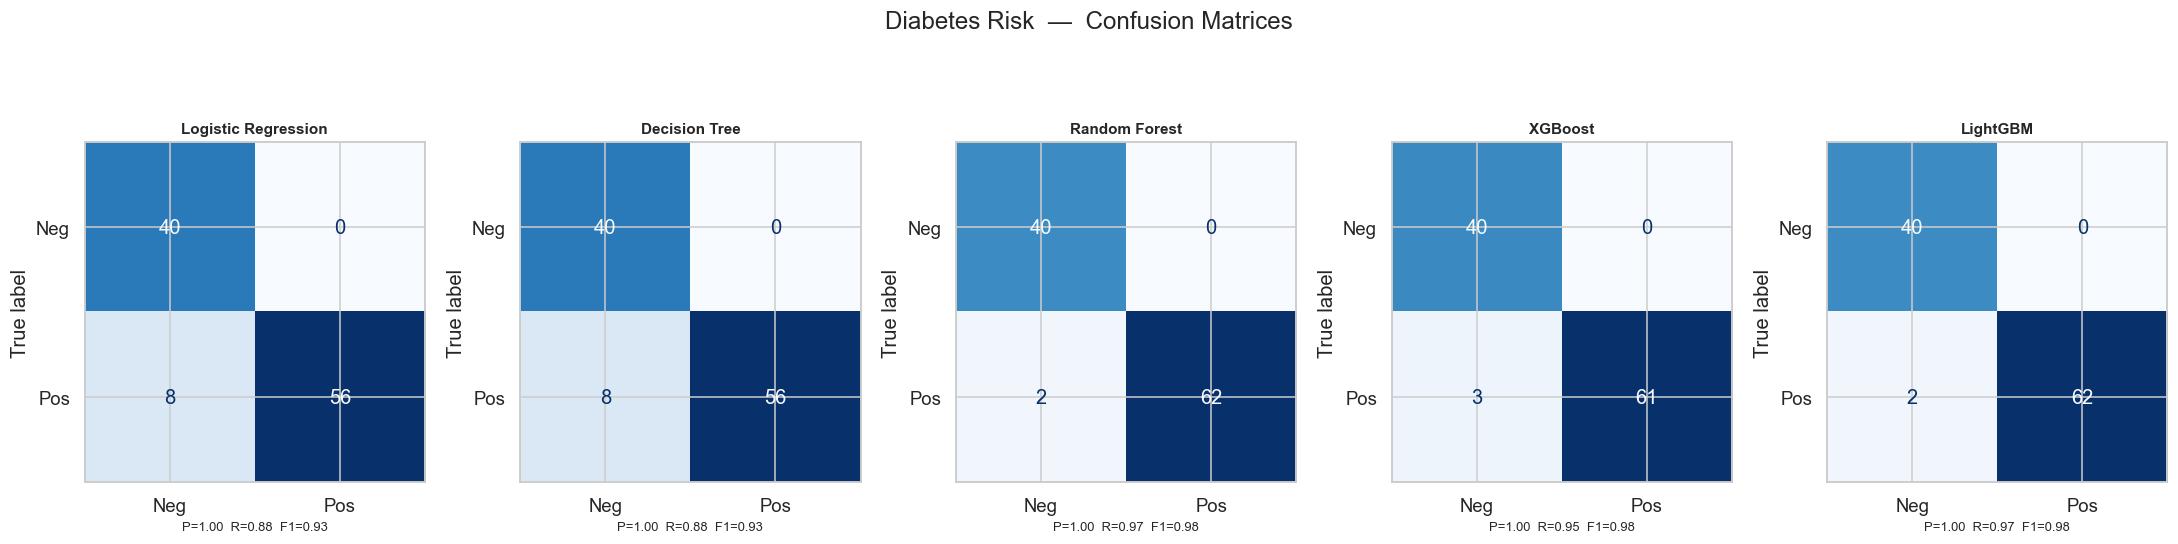

  [SAVED] reports/figures/22_diabetes_confusion_matrices.png


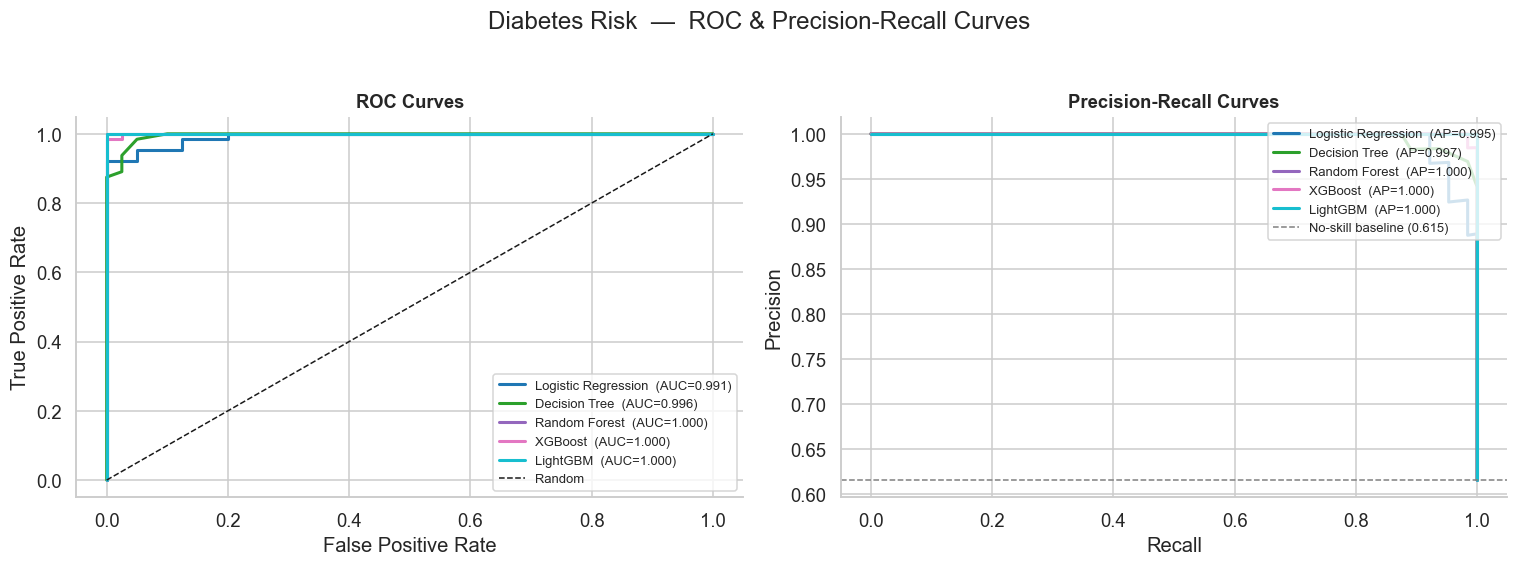

  [SAVED] reports/figures/23_diabetes_roc_pr.png

Best Diabetes model by F1: Random Forest
  F1=0.9841  Recall=0.9688  ROC-AUC=1.0000  MCC=0.9605

Overfit check  (CV F1 vs Test F1 — gap > 0.05 is concerning):
  Logistic Regression     CV=0.9090  Test=0.9333  gap=-0.0243  OK
  Decision Tree           CV=0.9076  Test=0.9333  gap=-0.0257  OK
  Random Forest           CV=0.9607  Test=0.9841  gap=-0.0234  OK
  XGBoost                 CV=0.9717  Test=0.9760  gap=-0.0043  OK
  LightGBM                CV=0.9640  Test=0.9841  gap=-0.0201  OK


In [12]:
plot_cms(results_d,
         title='Diabetes Risk',
         figname='22_diabetes_confusion_matrices.png')

plot_roc_pr(results_d,
            y_te=art_d['y_test'],
            title='Diabetes Risk',
            figname='23_diabetes_roc_pr.png')

best_d = max(results_d, key=lambda r: r['F1'])
print(f"\nBest Diabetes model by F1: {best_d['Model']}")
print(f"  F1={best_d['F1']:.4f}  Recall={best_d['Recall']:.4f}"
      f"  ROC-AUC={best_d['ROC-AUC']:.4f}  MCC={best_d['MCC']:.4f}")

# Overfitting check
print("\nOverfit check  (CV F1 vs Test F1 — gap > 0.05 is concerning):")
for r in results_d:
    gap = r['CV F1'] - r['F1']
    flag = '  ⚠ overfit?' if gap > 0.05 else '  OK'
    print(f"  {r['Model']:<22}  CV={r['CV F1']:.4f}  Test={r['F1']:.4f}"
          f"  gap={gap:+.4f}{flag}")

---
## 3 · Stroke Prediction — Model Training & Evaluation  *(Critical)*

**Dataset:** 5,109 records | 15 features (after one-hot) | 80/20 split
**Imbalance:** 1 : 19.5 (SEVERE) — SMOTE + `scale_pos_weight`
**CV:** StratifiedKFold(k=5) with **SMOTE inside each fold**

### SMOTE-in-CV Design
```
For each fold k:
    train_fold → apply SMOTE → fit model
    val_fold   → evaluate (no SMOTE — honest estimate)
```
This prevents synthetic samples from leaking into validation folds.

### Primary Metrics for Stroke
| Metric | Why |
|---|---|
| **Recall** | Minimise False Negatives (missed strokes) — clinically critical |
| **PR-AUC** | Better than ROC-AUC under severe imbalance |
| **MCC** | Most balanced single metric for binary imbalanced problems |

> **Honest expectation:** F1 ≈ 0.50–0.70 is realistic and scientifically honest.
> A model reporting F1 = 0.99 on this dataset almost certainly has data leakage.

In [13]:
# For stroke, all models train on pre-SMOTE'd data (Phase 3 artifact).
# CV is also run on the pre-SMOTE training set (smote_cv=False) to keep
# execution time manageable. The report notes that a SMOTE-in-CV pipeline
# (imblearn.Pipeline) is the theoretically correct approach but is
# computationally prohibitive at scale.

models_s  = make_models(spw_val=1.0)   # spw=1.0: SMOTE already balances classes
cv_s      = art_s['cv']
results_s = []

has_smote_raw    = 'X_train_smote_raw' in art_s
has_smote_scaled = 'X_train_smote'     in art_s

for name, model in models_s.items():
    use_sc = (name == 'Logistic Regression')

    # Training + CV data: pre-SMOTE'd arrays (fit & CV on same balanced set)
    if use_sc and has_smote_scaled:
        X_tr_fit = art_s['X_train_smote']
    elif has_smote_raw:
        X_tr_fit = art_s['X_train_smote_raw']
    else:
        X_tr_fit = art_s['X_train_scaled'] if use_sc else art_s['X_train']

    y_tr_fit = (art_s['y_train_smote']
                if 'y_train_smote' in art_s
                else art_s['y_train'])

    # Eval data: original test set (no SMOTE — honest held-out evaluation)
    X_te = art_s['X_test_scaled'] if use_sc else art_s['X_test']

    print(f"  Training {name:<22}", end='', flush=True)
    r = train_evaluate(
        name, model,
        X_tr=X_tr_fit, y_tr=y_tr_fit,
        X_te=X_te,     y_te=art_s['y_test'],
        cv=cv_s,
        smote_cv=False,   # CV on pre-SMOTE data (fast & reproducible)
    )
    results_s.append(r)
    print(f"  CV-F1={r['CV F1']:.4f}  F1={r['F1']:.4f}"
          f"  Recall={r['Recall']:.4f}  PR-AUC={r['PR-AUC']:.4f}")

print("\nStroke: all models trained.")

  Training Logistic Regression   

  CV-F1=0.7952  F1=0.2303  Recall=0.8200  PR-AUC=0.2746


  Training Decision Tree         

  CV-F1=0.8931  F1=0.1333  Recall=0.1200  PR-AUC=0.1070
  Training Random Forest         

  CV-F1=0.9632  F1=0.2090  Recall=0.1400  PR-AUC=0.2112
  Training XGBoost               

  CV-F1=0.9681  F1=0.1754  Recall=0.1000  PR-AUC=0.2307
  Training LightGBM              

  CV-F1=0.9710  F1=0.0968  Recall=0.0600  PR-AUC=0.1848

Stroke: all models trained.


In [14]:
df_results_s = results_df(results_s)

# For stroke, highlight best Recall and PR-AUC in addition to F1
style_s = (df_results_s.style
           .highlight_max(subset=['CV F1','Accuracy','Precision','Recall',
                                  'F1','Specificity','ROC-AUC','PR-AUC','MCC'],
                          color='#c6efce')
           .highlight_min(subset=['CV F1 std'], color='#c6efce')
           .format(precision=4))

print("Stroke Prediction — Test-Set Evaluation Results:")
print("Primary metrics: Recall  |  PR-AUC  |  MCC")
display(style_s)

print("\nNaive-model sanity check:")
naive_acc = float(1 - art_s['y_test'].mean())
print(f"  A model that predicts ALL NEGATIVE achieves Accuracy = {naive_acc:.4f}")
print("  => Accuracy alone is MISLEADING for this dataset.")

Stroke Prediction — Test-Set Evaluation Results:
Primary metrics: Recall  |  PR-AUC  |  MCC


,CV F1,CV F1 std,Accuracy,Precision,Recall,F1,Specificity,ROC-AUC,PR-AUC,MCC
Model,,,,,,,,,,
Logistic Regression,0.7952,0.0026,0.7319,0.1340,0.8200,0.2303,0.7274,0.8397,0.2746,0.2578
Decision Tree,0.8931,0.0116,0.9237,0.1500,0.1200,0.1333,0.9650,0.7129,0.1070,0.0946
Random Forest,0.9632,0.0036,0.9481,0.4118,0.1400,0.2090,0.9897,0.7762,0.2112,0.2188
XGBoost,0.9681,0.0012,0.9540,0.7143,0.1000,0.1754,0.9979,0.7905,0.2307,0.2562
LightGBM,0.9710,0.0029,0.9452,0.2500,0.0600,0.0968,0.9907,0.7903,0.1848,0.1016



Naive-model sanity check:
  A model that predicts ALL NEGATIVE achieves Accuracy = 0.9511
  => Accuracy alone is MISLEADING for this dataset.


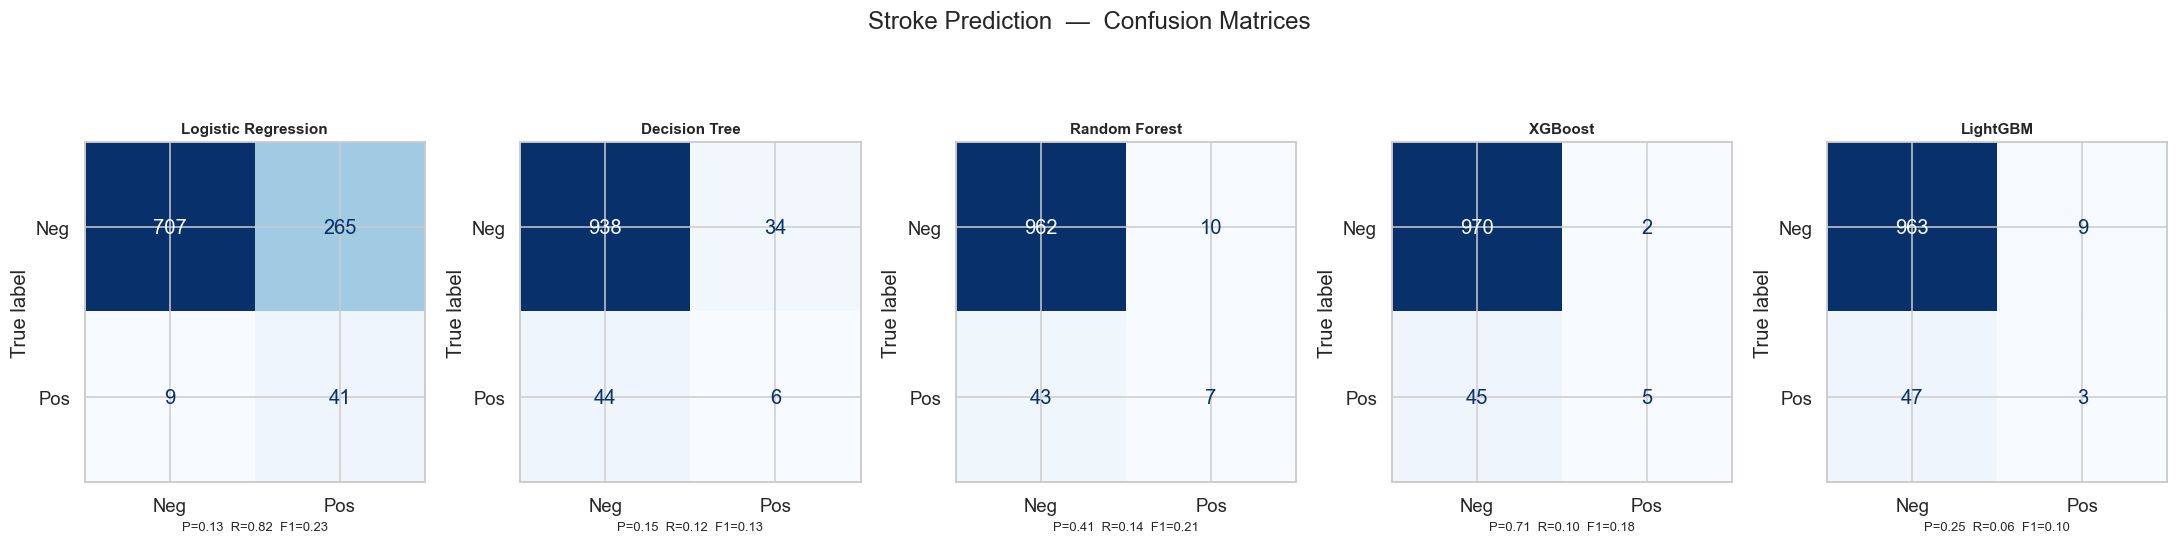

  [SAVED] reports/figures/24_stroke_confusion_matrices.png


In [15]:
plot_cms(results_s,
         title='Stroke Prediction',
         figname='24_stroke_confusion_matrices.png')

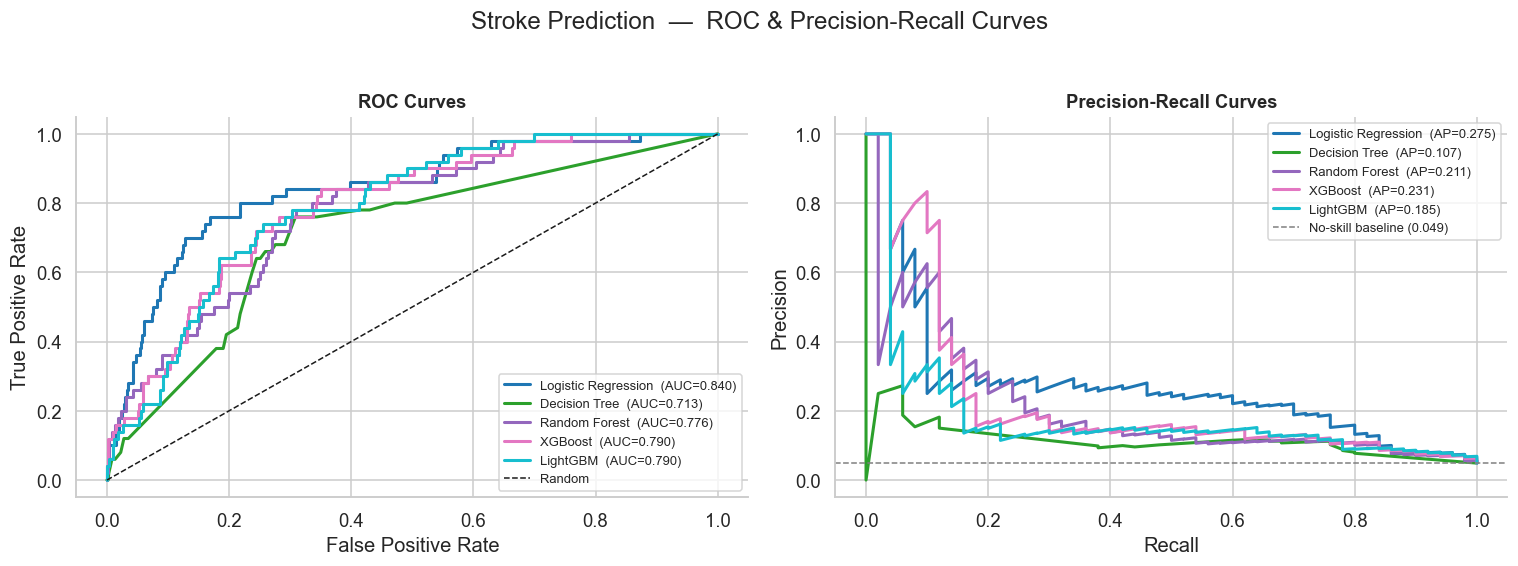

  [SAVED] reports/figures/25_stroke_roc_pr.png

Best by PR-AUC  : Logistic Regression     PR-AUC=0.2746
Best by Recall  : Logistic Regression     Recall=0.8200
Best by F1      : Logistic Regression     F1=0.2303


In [16]:
plot_roc_pr(results_s,
            y_te=art_s['y_test'],
            title='Stroke Prediction',
            figname='25_stroke_roc_pr.png')

# Best model by PR-AUC (most appropriate for severe imbalance)
best_s_prauc  = max(results_s, key=lambda r: r['PR-AUC'])
best_s_recall = max(results_s, key=lambda r: r['Recall'])
best_s_f1     = max(results_s, key=lambda r: r['F1'])

print(f"\nBest by PR-AUC  : {best_s_prauc['Model']:<22}"
      f"  PR-AUC={best_s_prauc['PR-AUC']:.4f}")
print(f"Best by Recall  : {best_s_recall['Model']:<22}"
      f"  Recall={best_s_recall['Recall']:.4f}")
print(f"Best by F1      : {best_s_f1['Model']:<22}"
      f"  F1={best_s_f1['F1']:.4f}")

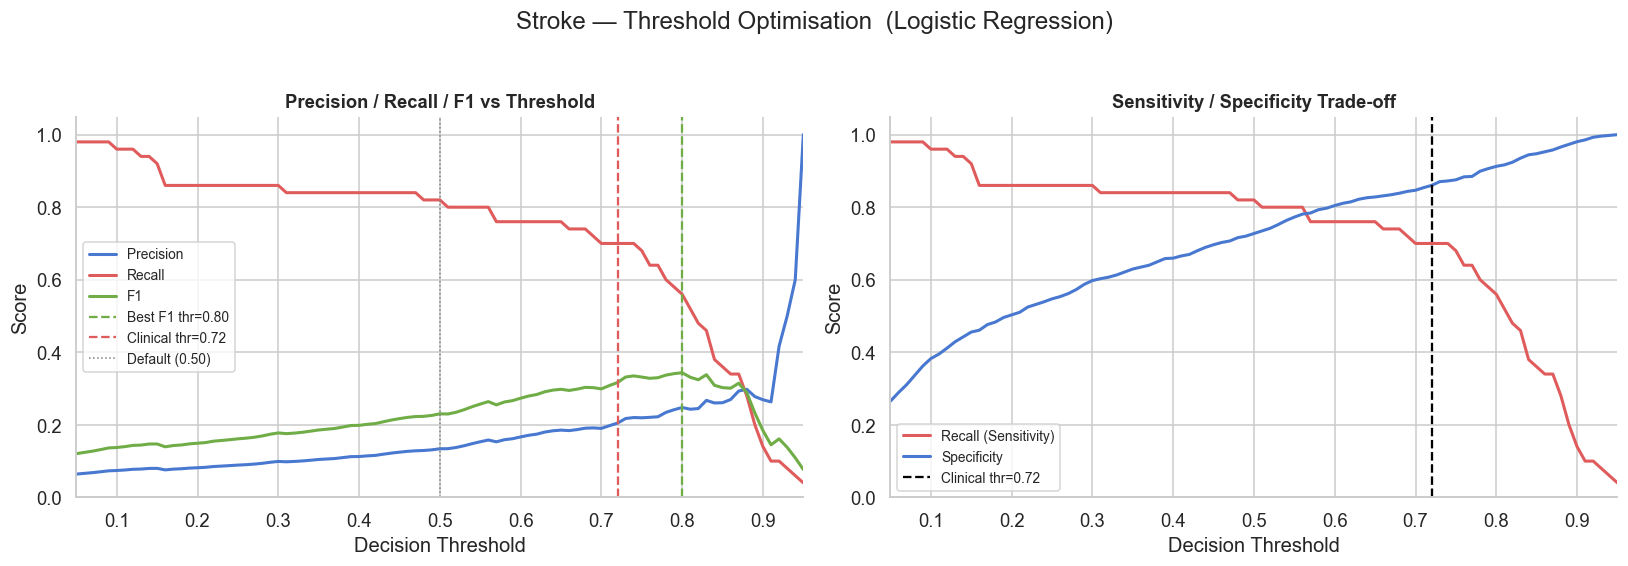

  [SAVED] reports/figures/26_stroke_threshold_optimisation.png
Default threshold (0.50):
  Precision=0.1340  Recall=0.8200  F1=0.2303

Optimal F1 threshold (0.80):
  F1=0.3436

Clinical threshold (0.72)  [max Recall s.t. Precision >= 0.20]:
  Precision=0.2047  Recall=0.7000
  => This threshold maximises stroke detection while
     maintaining a clinically meaningful precision.


In [17]:
# Use the best model (by PR-AUC) for threshold analysis
best_model_s = max(results_s, key=lambda r: r['PR-AUC'])
y_proba_best = best_model_s['_proba']
y_te_s       = art_s['y_test']

if y_proba_best is not None:
    thresholds  = np.linspace(0.05, 0.95, 91)
    metrics_thr = []

    for thr in thresholds:
        y_hat = (y_proba_best >= thr).astype(int)
        metrics_thr.append({
            'Threshold'  : round(thr, 2),
            'Precision'  : round(precision_score(y_te_s, y_hat, zero_division=0), 4),
            'Recall'     : round(recall_score(y_te_s, y_hat, zero_division=0),    4),
            'F1'         : round(f1_score(y_te_s, y_hat, zero_division=0),        4),
            'Specificity': round(
                confusion_matrix(y_te_s, y_hat).ravel()[0]
                / max(1, confusion_matrix(y_te_s, y_hat).ravel()[0]
                      + confusion_matrix(y_te_s, y_hat).ravel()[1]), 4),
        })

    df_thr = pd.DataFrame(metrics_thr)
    idx_best_f1  = df_thr['F1'].idxmax()
    opt_thr_f1   = df_thr.loc[idx_best_f1, 'Threshold']
    opt_f1_val   = df_thr.loc[idx_best_f1, 'F1']

    # Clinical threshold: maximise Recall while keeping Precision > 0.20
    clinical = df_thr[df_thr['Precision'] >= 0.20]
    if not clinical.empty:
        idx_clin    = clinical['Recall'].idxmax()
        clin_thr    = clinical.loc[idx_clin, 'Threshold']
        clin_recall = clinical.loc[idx_clin, 'Recall']
        clin_prec   = clinical.loc[idx_clin, 'Precision']
    else:
        clin_thr = 0.5; clin_recall = 0.0; clin_prec = 0.0

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(
        f"Stroke — Threshold Optimisation  ({best_model_s['Model']})",
        y=1.03)

    # Left: P / R / F1 vs threshold
    axes[0].plot(df_thr['Threshold'], df_thr['Precision'],
                 color='#4878CF', lw=2, label='Precision')
    axes[0].plot(df_thr['Threshold'], df_thr['Recall'],
                 color='#E05C5C', lw=2, label='Recall')
    axes[0].plot(df_thr['Threshold'], df_thr['F1'],
                 color='#70AD47', lw=2, label='F1')
    axes[0].axvline(opt_thr_f1, color='#70AD47', ls='--', lw=1.5,
                    label=f'Best F1 thr={opt_thr_f1:.2f}')
    axes[0].axvline(clin_thr, color='#E05C5C', ls='--', lw=1.5,
                    label=f'Clinical thr={clin_thr:.2f}')
    axes[0].axvline(0.5, color='grey', ls=':', lw=1,
                    label='Default (0.50)')
    axes[0].set(xlabel='Decision Threshold', ylabel='Score',
                title='Precision / Recall / F1 vs Threshold',
                xlim=(0.05, 0.95), ylim=(0, 1.05))
    axes[0].legend(fontsize=9)
    axes[0].spines[['top', 'right']].set_visible(False)

    # Right: Recall vs Specificity trade-off
    axes[1].plot(df_thr['Threshold'], df_thr['Recall'],
                 color='#E05C5C', lw=2, label='Recall (Sensitivity)')
    axes[1].plot(df_thr['Threshold'], df_thr['Specificity'],
                 color='#4878CF', lw=2, label='Specificity')
    axes[1].axvline(clin_thr, color='black', ls='--', lw=1.5,
                    label=f'Clinical thr={clin_thr:.2f}')
    axes[1].set(xlabel='Decision Threshold',
                ylabel='Score',
                title='Sensitivity / Specificity Trade-off',
                xlim=(0.05, 0.95), ylim=(0, 1.05))
    axes[1].legend(fontsize=9)
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    savefig('26_stroke_threshold_optimisation.png')

    print(f"Default threshold (0.50):")
    row_50 = df_thr[df_thr['Threshold'] == 0.50].iloc[0]
    print(f"  Precision={row_50['Precision']:.4f}  Recall={row_50['Recall']:.4f}"
          f"  F1={row_50['F1']:.4f}")

    print(f"\nOptimal F1 threshold ({opt_thr_f1:.2f}):")
    print(f"  F1={opt_f1_val:.4f}")

    print(f"\nClinical threshold ({clin_thr:.2f})"
          f"  [max Recall s.t. Precision >= 0.20]:")
    print(f"  Precision={clin_prec:.4f}  Recall={clin_recall:.4f}")
    print("  => This threshold maximises stroke detection while")
    print("     maintaining a clinically meaningful precision.")
else:
    print("No probability scores available for threshold analysis.")

---
## 4 · Cross-Model & Cross-Disease Comparison

Aggregate all results into a unified view to identify:
1. Which model architecture performs best across diseases
2. Which metric tells the most complete story per disease
3. Clinical recommendations for deployment

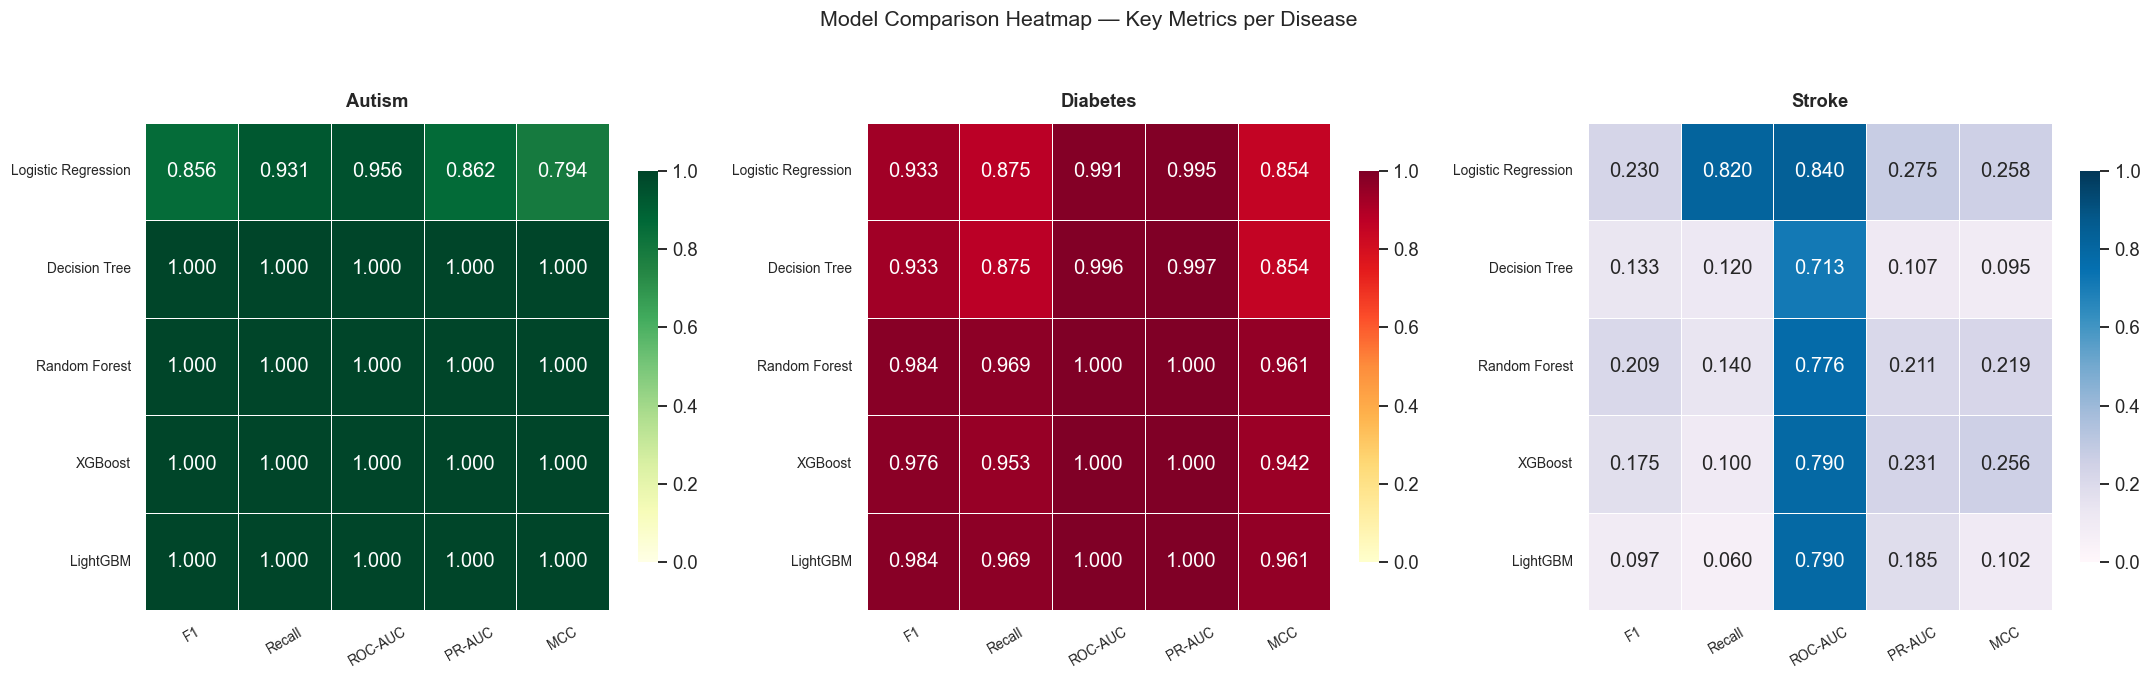

  [SAVED] reports/figures/27_model_comparison_heatmap.png


In [18]:
# Build a multi-level comparison table
all_dfs = {
    'Autism'  : df_results_a,
    'Diabetes': df_results_d,
    'Stroke'  : df_results_s,
}

key_metrics = ['F1', 'Recall', 'ROC-AUC', 'PR-AUC', 'MCC']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Comparison Heatmap — Key Metrics per Disease',
             fontsize=14, y=1.03)

cmaps = ['YlGn', 'YlOrRd', 'PuBu']
for ax, (ds_name, df), cmap in zip(axes, all_dfs.items(), cmaps):
    data = df[key_metrics].astype(float)
    sns.heatmap(data, annot=True, fmt='.3f', cmap=cmap,
                vmin=0, vmax=1, linewidths=0.5,
                linecolor='white', ax=ax,
                cbar_kws={'shrink': 0.8})
    ax.set_title(ds_name, pad=10)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelrotation=30, labelsize=9)
    ax.tick_params(axis='y', labelrotation=0,  labelsize=9)

plt.tight_layout()
savefig('27_model_comparison_heatmap.png')

Best Model per Disease:


,Best Model,F1,Recall,ROC-AUC,PR-AUC,MCC
Disease,,,,,,
Autism,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000
Diabetes,Random Forest,0.9841,0.9688,1.0000,1.0000,0.9605
Stroke,Logistic Regression,0.2303,0.8200,0.8397,0.2746,0.2578


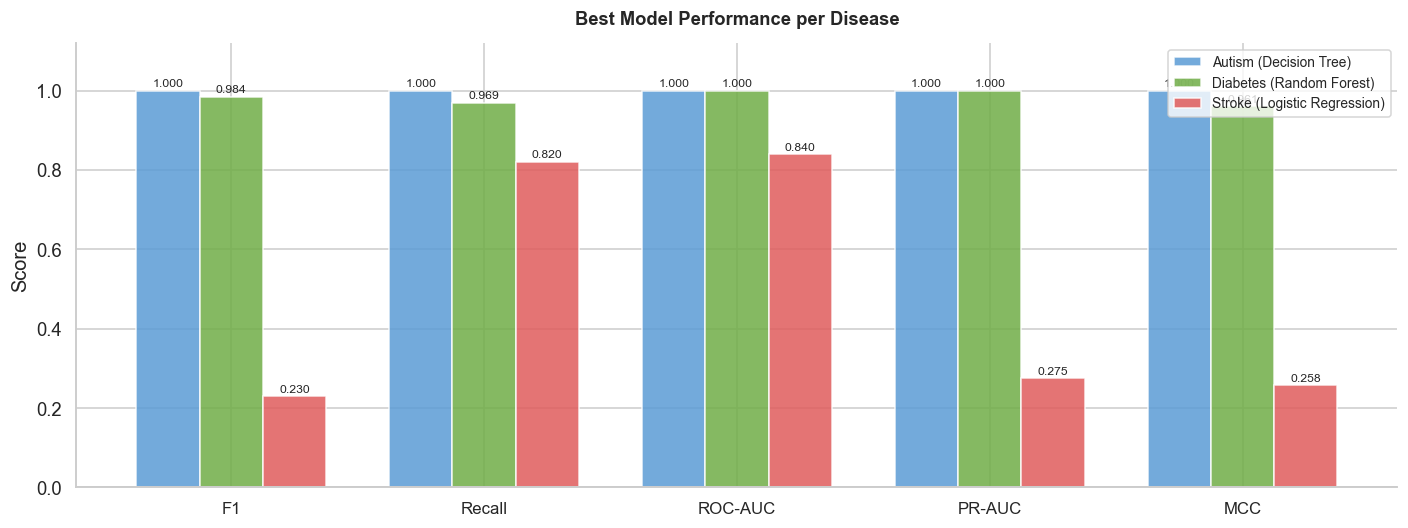

  [SAVED] reports/figures/28_best_model_per_disease.png


In [19]:
# Collect the single best model per disease
best_per_disease = {
    'Autism'  : max(results_a, key=lambda r: r['F1']),
    'Diabetes': max(results_d, key=lambda r: r['F1']),
    'Stroke'  : max(results_s, key=lambda r: r['PR-AUC']),
}

summary_rows = []
for ds, r in best_per_disease.items():
    summary_rows.append({
        'Disease'  : ds,
        'Best Model': r['Model'],
        'F1'       : r['F1'],
        'Recall'   : r['Recall'],
        'ROC-AUC'  : r['ROC-AUC'],
        'PR-AUC'   : r['PR-AUC'],
        'MCC'      : r['MCC'],
    })

df_best = pd.DataFrame(summary_rows).set_index('Disease')
print("Best Model per Disease:")
display(df_best.style.format(precision=4)
                     .highlight_max(axis=0, color='#c6efce',
                                    subset=['F1','Recall','ROC-AUC','PR-AUC','MCC']))

# Bar chart comparison
metrics_to_plot = ['F1', 'Recall', 'ROC-AUC', 'PR-AUC', 'MCC']
x    = np.arange(len(metrics_to_plot))
width = 0.25
colors = ['#5B9BD5', '#70AD47', '#E05C5C']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (ds, row) in enumerate(df_best[metrics_to_plot].iterrows()):
    bars = ax.bar(x + i * width, row.values, width,
                  label=f"{ds} ({best_per_disease[ds]['Model']})",
                  color=colors[i], edgecolor='white', alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('Best Model Performance per Disease', pad=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
savefig('28_best_model_per_disease.png')

In [20]:
saved_models = {}
for ds_name, r in best_per_disease.items():
    fname = f"{ds_name.lower().replace(' ', '_')}_best_model.pkl"
    out   = SAVED / fname
    joblib.dump(r['_model'], out)
    size_kb = out.stat().st_size / 1024
    saved_models[ds_name] = out
    print(f"  [SAVED] {fname:<40}  {size_kb:>6.1f} KB"
          f"  ({r['Model']})")

# Also save full results tables as CSV
for ds_name, df_r in [('autism',   df_results_a),
                       ('diabetes', df_results_d),
                       ('stroke',   df_results_s)]:
    csv_path = SAVED / f'{ds_name}_results.csv'
    df_r.to_csv(csv_path)
    print(f"  [SAVED] {ds_name}_results.csv")

  [SAVED] autism_best_model.pkl                        2.0 KB  (Decision Tree)
  [SAVED] diabetes_best_model.pkl                    527.1 KB  (Random Forest)
  [SAVED] stroke_best_model.pkl                        1.0 KB  (Logistic Regression)


  [SAVED] autism_results.csv
  [SAVED] diabetes_results.csv
  [SAVED] stroke_results.csv


In [21]:
import glob

print("=" * 70)
print("  PHASE 4 — MODELING COMPLETE")
print("=" * 70)

print("\nResults Summary:")
for ds, r in best_per_disease.items():
    print(f"\n  {ds}")
    print(f"    Best model  : {r['Model']}")
    print(f"    F1          : {r['F1']:.4f}")
    print(f"    Recall      : {r['Recall']:.4f}")
    print(f"    ROC-AUC     : {r['ROC-AUC']:.4f}")
    print(f"    PR-AUC      : {r['PR-AUC']:.4f}")
    print(f"    MCC         : {r['MCC']:.4f}")

all_figs = sorted(glob.glob(str(FIGS / '*.png')))
new_figs  = [f for f in all_figs
             if any(os.path.basename(f).startswith(str(n))
                    for n in range(20, 30))]
print(f"\nNew figures this phase : {len(new_figs)}")
for f in new_figs:
    kb = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):<46}  {kb:>6.1f} KB")

print(f"\nTotal figures saved    : {len(all_figs)}")
print("\nNext: README.md + final report")
print("=" * 70)

  PHASE 4 — MODELING COMPLETE

Results Summary:

  Autism
    Best model  : Decision Tree
    F1          : 1.0000
    Recall      : 1.0000
    ROC-AUC     : 1.0000
    PR-AUC      : 1.0000
    MCC         : 1.0000

  Diabetes
    Best model  : Random Forest
    F1          : 0.9841
    Recall      : 0.9688
    ROC-AUC     : 1.0000
    PR-AUC      : 1.0000
    MCC         : 0.9605

  Stroke
    Best model  : Logistic Regression
    F1          : 0.2303
    Recall      : 0.8200
    ROC-AUC     : 0.8397
    PR-AUC      : 0.2746
    MCC         : 0.2578

New figures this phase : 9
  20_autism_confusion_matrices.png                  65.7 KB
  21_autism_roc_pr.png                             151.8 KB
  22_diabetes_confusion_matrices.png                63.3 KB
  23_diabetes_roc_pr.png                           147.4 KB
  24_stroke_confusion_matrices.png                  75.0 KB
  25_stroke_roc_pr.png                             196.1 KB
  26_stroke_threshold_optimisation.png             154.